# **Predicting Newsletter Subscription from Player Characteristics**

**DSCI 100 Minecraft Project - Daniel Kwok (46358065)**

## Introduction

The rise of online gaming platforms has led to an explosion of behavioral data, offering unique opportunities to study player engagement at scale. In this project, we collaborate with a research group from the University of British Columbia (UBC), led by Dr. Frank Wood, which operates a Minecraft server that tracks player activity. As the platform grows, understanding who engages with the game—and how—is essential for resource planning and targeted outreach. A key interest is identifying what kinds of players are most likely to subscribe to a game-related newsletter. Newsletter subscriptions often signal deeper engagement and interest, making this an important outcome to predict. 

Thus my question for this project is: **Can we predict whether a player will subscribe to the newsletter based on their age, hours played, and experience level in players dataset?** To answer this, we will use a knn classifier algorithm.

By analyzing the characteristics of hours played and experience, we aim to uncover patterns that differentiate subscribers from non-subscribers. We will then color each player based on their experience level as well. These insights can support the development of more personalized and efficient player communication strategies. 

### Data Description
We are using the players.csv data sets from DSCI 100 to predict if a player from this server will subscribe or not. 
- `players.csv`: Information about each unique player (e.g., age, gender, experience level, played hours, and subscription status).

Description of columns in players.csv:
- **experience**: A factor indicating the player’s experience level (e.g., Pro, Veteran, Amateur, Regular)
- **subscribe**: A logical value (TRUE/FALSE) indicating whether the player subscribed to the newsletter
- **hashedEmail**: A unique, anonymized identifier for each player used to join datasets
- **played_hours**: The total number of hours the player has reported or accumulated playing the game
- **name**: The first name of the player (likely pseudonymized or fictional for privacy)
- **gender**: The gender of the player (e.g., Male, Female)
- **Age**: The age of the player, in years (numeric)

Based on the list above, we will be using played_hours and Age as predictors, to classify players on whether or not they have subscribed to the newsletter. 


## Methods and Results

#### Preprocessing and Exploratory data analysis

 1) Importing libraries and formatting graphs
 2) Importing the `players.csv` data and cleaning/tidying the data
 3) Splitting our data into training and testing sets
 4) Summarizing the training set to see initial patterns and what we might expect
 5) Visualizing the response variable and the predictors (`played_hours` and `Age`)


### Preprocessing and Exploratory Data Analysis

#### Importing libraries and formatting graphs

This code imports the libraries needed for the project. The tidyverse library provides tools for data manipulation and visualization, while tidymodels supports building and evaluating machine learning models. The repr library is used to control the size of plots, and RColorBrewer offers color palettes to enhance graph readability. Finally, the options() function sets the default plot dimensions to make visualizations clearer and more consistent.

In [1]:
#Importing libraries I will use in this project
library(tidyverse)
library(tidymodels)
library(repr)
library(RColorBrewer)
# formatting graphs
options(repr.plot.width = 12, repr.plot.height = 6)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

#### Reading the Dataset and Cleaning/Tidying data

The `read_csv` function is used to load the data from the data folder in the current directory.

The `select` function is then applied to remove the hashedEmail, name, and gender columns, as these are not used as predictors for the subscribe variable. Observations with missing Age values and played hours that are less than 0 are filtered out, since they do not contribute to classification or prediction. The experience variable is retained to allow colouring of data points for potential pattern visualization.

Finally, the subscribe variable is converted to a factor using the `mutate` function, as it serves as the response variable in the prediction task.

In [2]:
players_data <- read_csv("data/players.csv") |>
  select(-name, -hashedEmail, -gender) |>
  filter(!is.na(Age), played_hours > 0) |>
  mutate(subscribe = as.factor(subscribe))

head(players_data)
nrow(players_data)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,played_hours,Age
<chr>,<fct>,<dbl>,<dbl>
Pro,TRUE,30.3,9
Veteran,TRUE,3.8,17
Amateur,TRUE,0.7,21
Regular,TRUE,0.1,21
Amateur,TRUE,0.1,17
Veteran,TRUE,1.6,23


[1] 109

*figure 1*

### Splitting our data into training and testing sets

Before developing the model, the dataset must be divided into training and testing sets. Because the goal is to predict the subscribe column, stratification is performed based on this variable.

The `initial_split` function is used to randomly partition the data, assigning 75% to the training set and 25% to the testing set. This approach maintains consistent class proportions across both sets and ensures that the model is trained on a substantial portion of the data while preserving sufficient observations for reliable evaluation.

In [3]:
#splitting data frame
set.seed(5)
players_split <- initial_split(players_data, prop = 0.75, strata = subscribe)

players_training <- training(players_split)
players_testing <- testing(players_split)


nrow(players_training)
nrow(players_testing)
head(players_training)

[1] 81

[1] 28

experience,subscribe,played_hours,Age
<chr>,<fct>,<dbl>,<dbl>
Veteran,FALSE,0.1,18
Veteran,FALSE,1.4,25
Amateur,FALSE,0.9,18
Veteran,FALSE,0.1,22
Beginner,FALSE,0.2,37
Veteran,FALSE,0.1,18


*figure 2*

In the above code, I split the data into a training set to build our model on, and a testing set to, well, test it. Using initial_split allowed us to shuffle the data before splitting (removing bias and order) and stratify the data by diag so that an equal proportion of each is in each set.

There are 81 rows (75%) in the training set and 28 rows (25%) in the testing set. This gives us enough data to train the classifier on, as well as enough to test it on later. This means our classifier is going to be reliable.

Moving forward, we will only use the training set until the very end.

### Summarizing the data

Before proceeding with modeling, it is important to confirm whether the two classes differ in their average played hours and age.

This can be assessed by using `group_by` and `summarize` to generate a table showing the mean values for each predictor across the classes.

In [4]:
#summarizing to get mean each predictor + total no. of rows per class
players_summary <- players_training |>
                    group_by(subscribe) |>
                    summarize(mean_played_hours = mean(played_hours), 
                              mean_age = mean(Age),
                              n_of_players = n())

players_summary
     

subscribe,mean_played_hours,mean_age,n_of_players
<fct>,<dbl>,<dbl>,<int>
FALSE,0.85000,21.22222,18
TRUE,12.71905,20.11111,63


*figure 3*

The data were summarized by grouping on subscribe and calculating the mean values for played hours and age. 

The summary indicates that players usually subsribed generally exhibit higher played hours and are a bit younger. These trends are expected to inform the classifier's ability to distinguish between those who subscribed to the newletter and those who did not. Additionally, the distribution of TRUE and FALSE diagnoses in the training set appears to not be balanced. We will further explore the data upsampled and not upsampled in the next steps.

### Visualizing the realtionship between predictors and class

To begin exploring the relationship between player demographics and engagement, I created a scatter plot using the training dataset. Specifically, I visualized each player's age against the total number of hours played, with points colored based on whether the player subscribed to the newsletter.

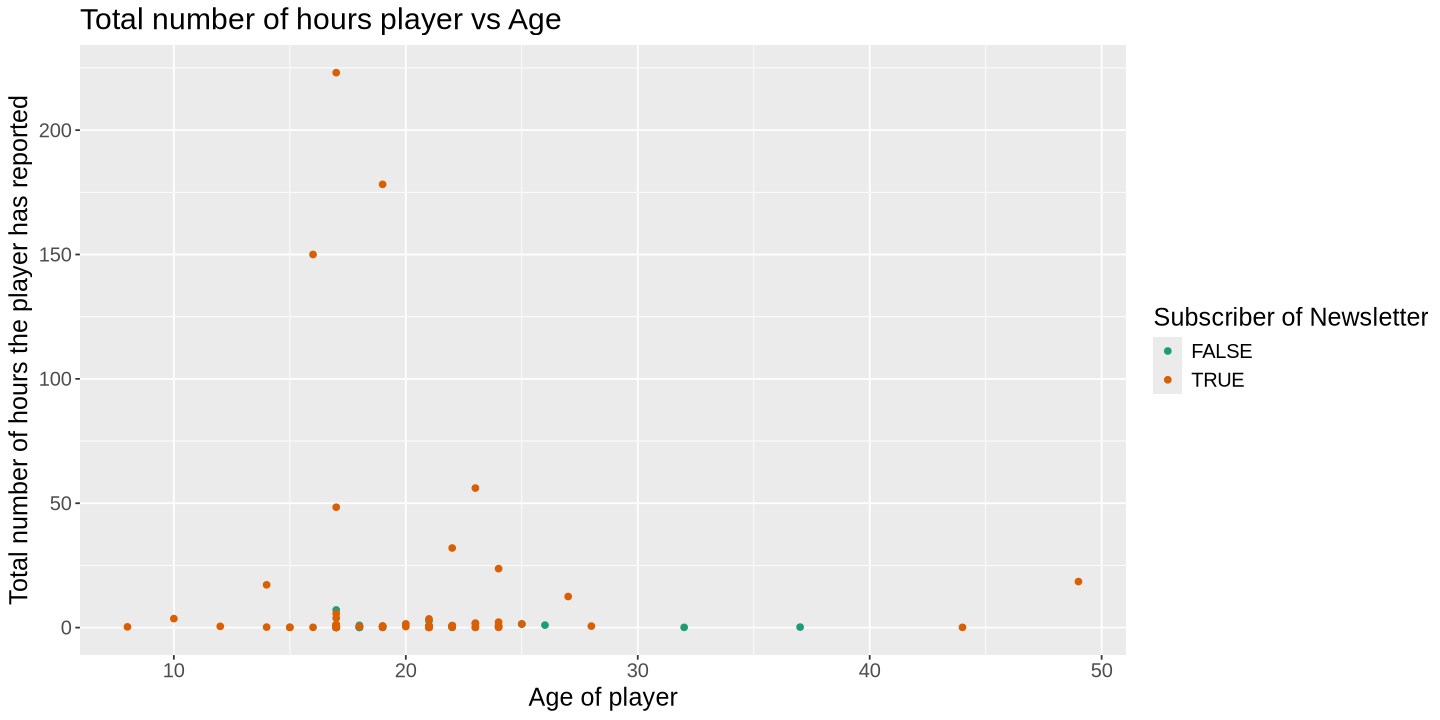

In [5]:
#plotting the training data
set.seed(5)
players_training_plot <- ggplot(players_training, aes(x = Age, y = played_hours, color = subscribe)) +
                 geom_point() +
                 labs(x = "Age of player", y = "Total number of hours the player has reported",
                      color = "Subscriber of Newsletter", title = "Total number of hours player vs Age") +
                 scale_color_brewer(palette = "Dark2") +
                 theme(text = element_text(size = 15))

players_training_plot

*figure 4*

This plot helps visualize patterns in the data and reveals potential associations between age, engagement (played hours), and newsletter subscription. The use of scale_color_brewer() improves color contrast for better differentiation, and increasing the text size makes the visualization more accessible for presentation or reporting.

As we notice alot of the points are gathered at the bottom so we will run the code again but scale it just to see the distrubution of the points better. We also want to visualize if there is meaningful relationship of those subscribed to their skill level/experience so we will add shape as well. 

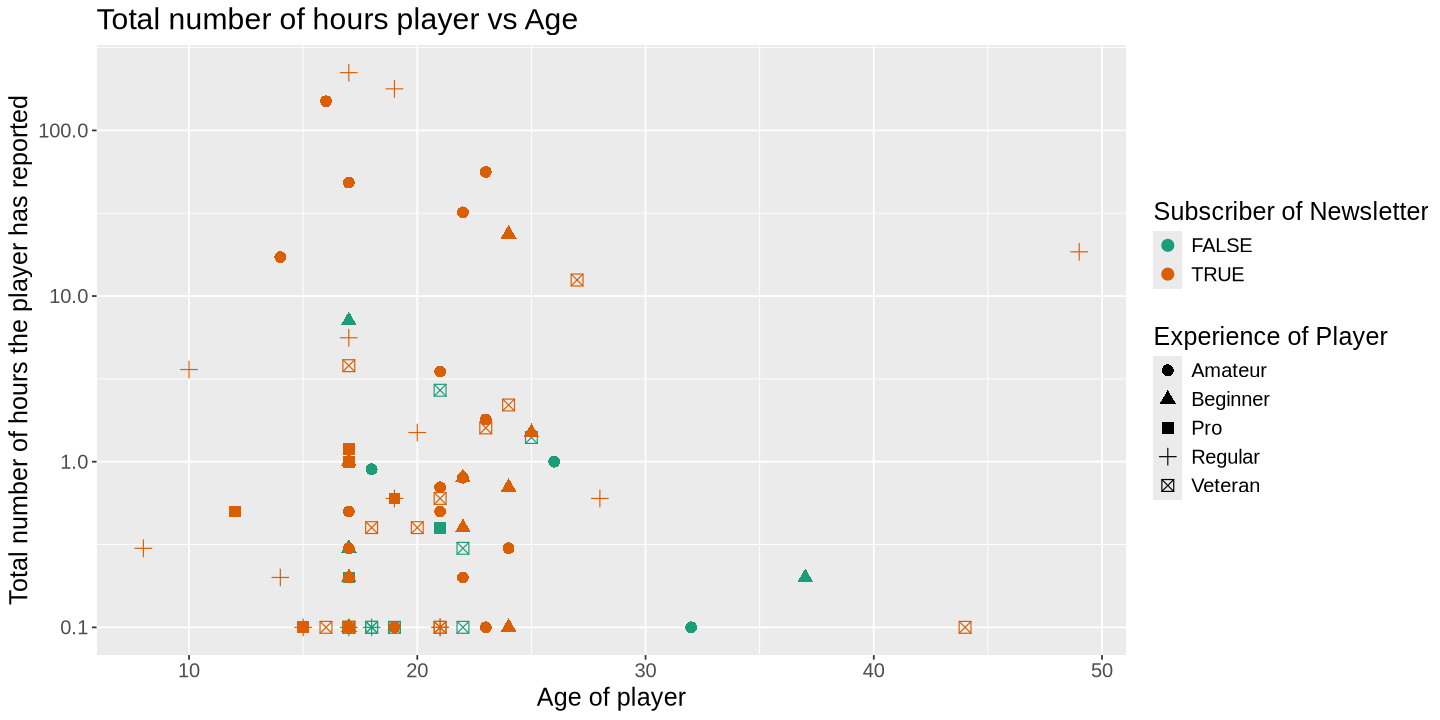

In [6]:
set.seed(5)
players_training_plot <- ggplot(players_training, aes(x = Age, y = played_hours, shape = experience, color = subscribe)) +
                 geom_point(size = 3) +
                 labs(x = "Age of player", y = "Total number of hours the player has reported",
                      color = "Subscriber of Newsletter", shape = "Experience of Player", title = "Total number of hours player vs Age") +
                 scale_color_brewer(palette = "Dark2") +
                 theme(text = element_text(size = 15)) + scale_y_log10()

players_training_plot

*figure 4*

This graph shows that players that are subscribed seen to have higher played hours and are a bit younger (orange). Seeing it in this form allows us to verify that there may be a pattern in this data but furthur classification will be necesssary. 

We can also see that the experience of the player does not play a huge factor in whether they are subscribed or not as they is a wide range of every type of experience in both categories of following the newsletter or not. 

We will continue and use classificaiton to determine if there is a relationship between the `played_hours` and `Age` categories to predict subscribers to the newsletter. 

# Finding the best $k$ Value

### Creating the model

To create our model, we should follow these steps: 

1) create a recipe that uses `players_training` to predict `subscribe` with our predictors
2) create a model specification that uses the k-nearest neighbors with `neighbors = tune()` to use cross validation
3) To split our data using folds which will help make sure the `subscribe` factor is straified
4) create a workflow with `tune_grid`
5) repeat the validation steps for the values of $k$ from 1 to 50

### Scenario of Not Upsampling

Earlier in the exploratory phase we noticed that there are quite a bit more true than false in our dataset. If we continue without upsampling what may happen?

As I explored this without upsampling I found that there is a extreme bias in the classification.

In [7]:
set.seed(5)

non_upsampled_recipe <- recipe(subscribe ~ Age + played_hours, data = players_training) %>%
  step_normalize(all_numeric_predictors())

# K-nearest neighbour model specification
knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
            set_engine("kknn") |>
            set_mode("classification")

# Perform 10 fold-cross valdiation
players_vfold <- vfold_cv(players_training, v = 10, strata = subscribe)

gridvals <- tibble(neighbors = c(1:50))

# Create workflow
knn_results2 <- workflow() |>
      add_recipe(non_upsampled_recipe) |>
      add_model(knn_spec) |>
      tune_grid(resamples = players_vfold, grid = gridvals) |>
      collect_metrics() |>
      filter(.metric == "accuracy") |>
      select(neighbors, mean) |>
      arrange(desc(mean))

head(knn_results2)

neighbors,mean
<int>,<dbl>
6,0.8083333
5,0.7958333
7,0.7815476
13,0.7797619
15,0.7797619
17,0.7797619


Here we can see that $k$ = 6 gives us 80.8% accuracy! This may seem good so we will continue but remember this is non-upsampled data. 

### Building the model (non upsampled data)

Now that we have this value for $k$ we can create the final specification with the neighbors = 6. We then will fit it to `players_training`

In [18]:
set.seed(5)

final_spec2 <- nearest_neighbor(weight_func="rectangular", neighbors = 11) |>
    set_engine("kknn") |>
    set_mode("classification")

players_fit2 <- workflow() |>
    add_recipe(non_upsampled_recipe) |>
    add_model(final_spec2) |>
    fit(data = players_training)

players_fit2

══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
1 Recipe Step

• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(11,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.1975309
Best kernel: rectangular
Best k: 11

### Over/underfitting data

We still should check if the model is under/overfit. If so we it would mean our data is unreliable. 

Warning message:
“tune samples were requested but there were 81 rows in the data. 76 will be used.”


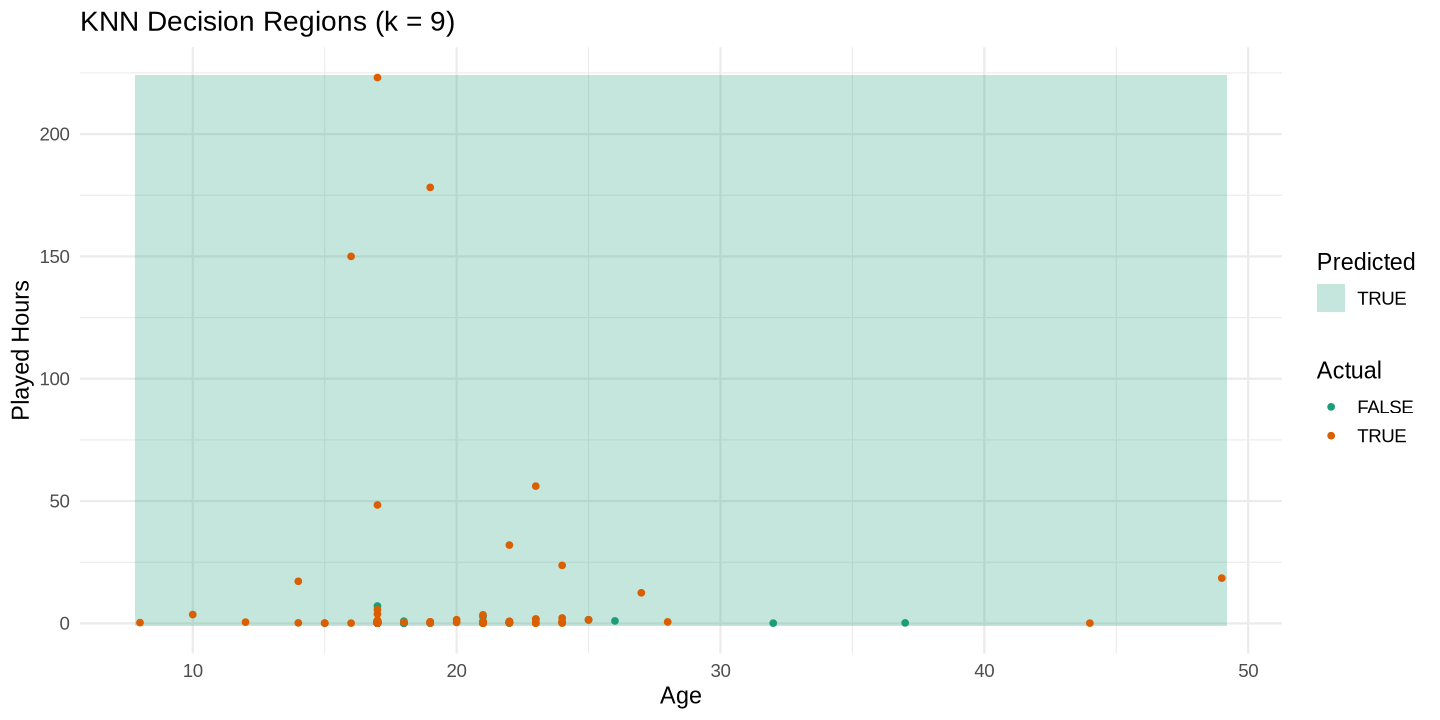

In [10]:
set.seed(5)

# 1. Model specification
knn_spec2 <- nearest_neighbor(weight_func = "rectangular", neighbors = 11) |>
  set_engine("kknn") |>
  set_mode("classification")

# 2. Workflow with recipe and model
players_fit2 <- workflow() |>
  add_recipe(non_upsampled_recipe) |>
  add_model(knn_spec) |>
  fit(data = players_training)  # use unscaled data; recipe handles scaling

# 3. Create grid in original (unscaled) feature space
age_grid <- seq(min(players_training$Age), max(players_training$Age), length.out = 100)
played_hours_grid <- seq(min(players_training$played_hours), max(players_training$played_hours), length.out = 100)

grid_df <- expand.grid(Age = age_grid, played_hours = played_hours_grid) |> as_tibble()

# 4. Predict on scaled grid (workflow will apply recipe)
grid_pred <- predict(players_fit2, new_data = grid_df)

# 5. Combine predictions with grid
grid_with_pred <- bind_cols(grid_df, grid_pred)

# 6. Plot with background decision regions and actual points
ggplot() +
  geom_tile(data = grid_with_pred, aes(x = Age, y = played_hours, fill = .pred_class), alpha = 0.25) +
  geom_point(data = players_training, aes(x = Age, y = played_hours, color = subscribe), size = 1.5) +
  labs(title = "KNN Decision Regions (k = 9)",
       x = "Age", y = "Played Hours", fill = "Predicted", color = "Actual") +
  scale_fill_brewer(palette = "Dark2") +
  scale_color_brewer(palette = "Dark2") +
  theme_minimal(base_size = 14)



We can see that it will 100 percent choose TRUE which is not a good model!

We can furthur explore this by actually testing it.

In [11]:
set.seed(5)

#predict
predictions <- predict(players_fit2, players_testing) |>
               bind_cols(players_testing)

#find the accuracy of the predictions
metrics<- predictions |>
    metrics(truth = subscribe, estimate = .pred_class) |>
    filter(.metric == "accuracy") 

metrics

#confusion matrix, identifies the areas the model is weak at classifying
conf_mat<- predictions |>
    conf_mat(truth = subscribe, estimate = .pred_class)
conf_mat

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.75


          Truth
Prediction FALSE TRUE
     FALSE     0    0
     TRUE      7   21

YAY it is 75% accurate.  However, further inspection of the confusion matrix reveals that the classifier predicted all outcomes as TRUE (subscribed), failing to identify any FALSE (non-subscribers). This is what we expected especially with the visualization

While this accuracy closely matches the majority class baseline (77.8%), it does not indicate meaningful learning. The model is biased toward the majority class and unable to distinguish between subscriber types. This suggests potential overfitting or class imbalance that limits the model's generalizability.

So instead we should upsample our data

### Upsampling our data 

Here we can follow the same steps as before but add the `step_upsample(subscribe, over_ration = 1)` in order to make sure there is not extreme bias

In [12]:
set.seed(5)
# Performing Standardization 
library(themis)

upsampled_recipe <- recipe(subscribe ~ Age + played_hours, data = players_training) %>%
  step_normalize(all_numeric_predictors()) %>%
  step_upsample(subscribe, over_ratio = 1)

# K-nearest neighbour model specification
knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
            set_engine("kknn") |>
            set_mode("classification")

# Perform 10 fold-cross valdiation
players_vfold <- vfold_cv(players_training, v = 10, strata = subscribe)

gridvals <- tibble(neighbors = c(1:50))

# Create workflow
knn_results <- workflow() |>
      add_recipe(upsampled_recipe) |>
      add_model(knn_spec) |>
      tune_grid(resamples = players_vfold, grid = gridvals) |>
      collect_metrics() |>
      filter(.metric == "accuracy") |>
      select(neighbors, mean) |>
      arrange(desc(mean))

head(knn_results)

neighbors,mean
<int>,<dbl>
1,0.6428571
2,0.6428571
9,0.6345238
10,0.6216270
27,0.6206349
28,0.6206349


Both $k$ = 1 and $k$ = 2 give us 64.2% accuracy. To pick one, we should plot a line graph of accuracy vs $k$

### Visualizing accuracy

Using geom_line, we will be able to view how "safe" each choice is, that is how big of a difference in accuracy a difference of $k$ ± 1 would cause. 
To do this, we need to plot a graph of accuracy vs neighbors.

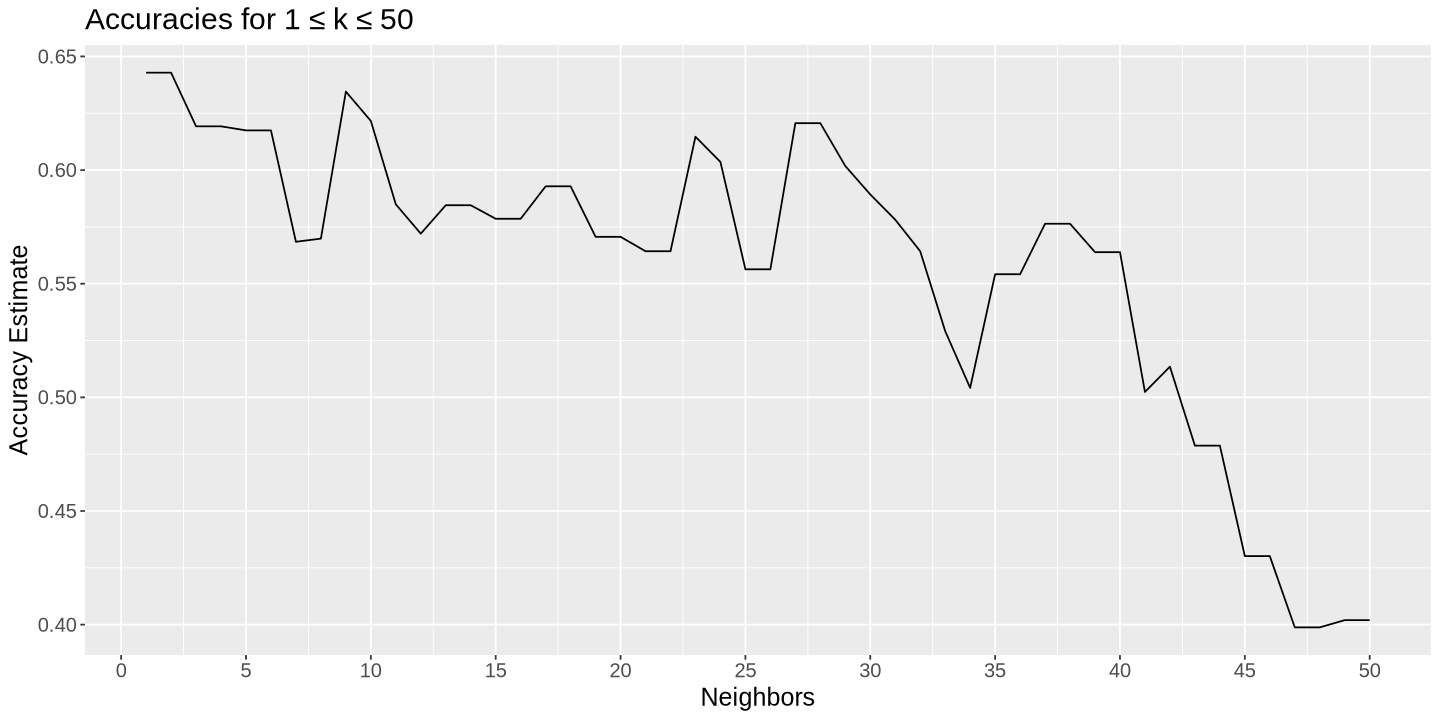

In [13]:
set.seed(5)
accuracy_versus_k <- ggplot(knn_results, aes(x = neighbors, y = mean))+
      geom_line() +
      labs(x = "Neighbors", y = "Accuracy Estimate", title = "Accuracies for 1 ≤ k ≤ 50") +
      scale_x_continuous(breaks = seq(0, 50, by = 5)) + # adjusting the x-axis
      theme(text = element_text(size = 15))

accuracy_versus_k    

Looking at the graph above, we should probably choose $k$ = 1 since $k$ = 2 drops afterwards. 

### Comparing to a majority classifier


In [14]:
set.seed(5)

#Comparing accuracy of classifier with majority classifier
players_proportions <- players_training |>
    group_by(subscribe) |> 
    summarize(n=n()) |>
    mutate(percent = 100*n/nrow(players_training))
players_proportions

subscribe,n,percent
<fct>,<int>,<dbl>
FALSE,18,22.22222
TRUE,63,77.77778


The original class distribution showed a significant imbalance, with 77.8% of observations in the TRUE (subscribed) category and only 22.2% in the FALSE (not subscribed) category. This kind of imbalance can bias a classifier toward the majority class, leading to poor predictive performance for the minority class.

To address this issue, I have applied upsampling to the training data using the `step_upsample()` function from the `themis` package. This technique duplicates instances of the minority class to match the frequency of the majority class, creating a balanced training dataset. Importantly, this upsampling was applied only to the training set (not the testing set), ensuring that the model learns from balanced data while still being evaluated on the original, imbalanced distribution.

As a result, although the raw data shows a large class imbalance, the model was trained in a way that mitigates the impact of this imbalance, improving its ability to correctly classify both subscribed and non-subscribed users.

### Building the final model with upsampled data

Again, we are building the final model with the upsampled data. 

In [19]:
set.seed(5)

final_spec <- nearest_neighbor(weight_func="rectangular", neighbors = 2) |>
    set_engine("kknn") |>
    set_mode("classification")

players_fit <- workflow() |>
    add_recipe(upsampled_recipe) |>
    add_model(final_spec) |>
    fit(data = players_training)

players_fit

══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
2 Recipe Steps

• step_normalize()
• step_upsample()

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(2,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.2063492
Best kernel: rectangular
Best k: 2

### Checking for over/underfitting

It is probably a good idea to check for over/underfitting especially since we upsampled it. 

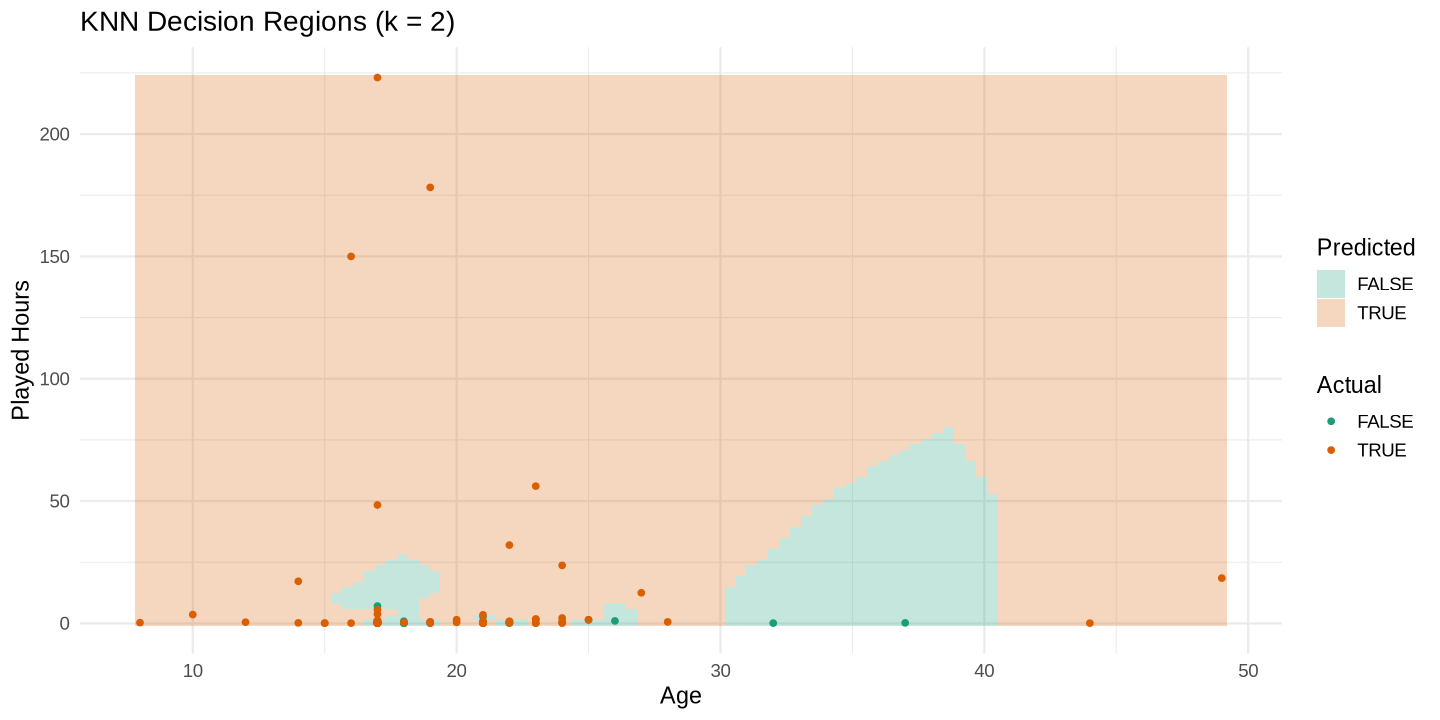

In [20]:
set.seed(5)

# 1. Model specification
knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 1) |>
  set_engine("kknn") |>
  set_mode("classification")

# 2. Workflow with recipe and model
players_fit <- workflow() |>
  add_recipe(upsampled_recipe) |>
  add_model(knn_spec) |>
  fit(data = players_training)  # use unscaled data; recipe handles scaling

# 3. Create grid in original (unscaled) feature space
age_grid <- seq(min(players_training$Age), max(players_training$Age), length.out = 100)
played_hours_grid <- seq(min(players_training$played_hours), max(players_training$played_hours), length.out = 100)

grid_df <- expand.grid(Age = age_grid, played_hours = played_hours_grid) |> as_tibble()

# 4. Predict on scaled grid (workflow will apply recipe)
grid_pred <- predict(players_fit, new_data = grid_df)

# 5. Combine predictions with grid
grid_with_pred <- bind_cols(grid_df, grid_pred)

# 6. Plot with background decision regions and actual points
ggplot() +
  geom_tile(data = grid_with_pred, aes(x = Age, y = played_hours, fill = .pred_class), alpha = 0.25) +
  geom_point(data = players_training, aes(x = Age, y = played_hours, color = subscribe), size = 1.5) +
  labs(title = "KNN Decision Regions (k = 2)",
       x = "Age", y = "Played Hours", fill = "Predicted", color = "Actual") +
  scale_fill_brewer(palette = "Dark2") +
  scale_color_brewer(palette = "Dark2") +
  theme_minimal(base_size = 14)



 Looking at the graph above the classifer is neither underfitting nor overfitting and therefore we can trust that our classifier will be able to predict new data. We can see unlike before is not completely one sided. 

### Testing our classifier

In [21]:
set.seed(5)

#predict
predictions <- predict(players_fit, players_testing) |>
               bind_cols(players_testing)

#find the accuracy of the predictions
metrics<- predictions |>
    metrics(truth = subscribe, estimate = .pred_class) |>
    filter(.metric == "accuracy") 

metrics

#confusion matrix, identifies the areas the model is weak at classifying
conf_mat<- predictions |>
    conf_mat(truth = subscribe, estimate = .pred_class)
conf_mat

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.5714286


          Truth
Prediction FALSE TRUE
     FALSE     2    7
     TRUE      5   14

Our classifier achieved an accuracy of 57.1%, correctly identifying 16 out of 28 users. The confusion matrix reveals that the model is less likely to incorrectly classify non-subscribers as subscribers (5 false positives) than to miss actual subscribers (7 false negatives). In other words, it tends to underpredict newsletter subscription rather than underpredict it.

This cautious approach may be acceptable depending on the intended application. For example, if the goal is to target potential subscribers with marketing content, it's preferable to include some non-subscribers rather than miss users who might be genuinely interested. However, the relatively low true negative count (2 out of 7 actual non-subscribers) suggests the model struggles to confidently identify users unlikely to subscribe.

Overall, while the classifier's accuracy leaves room for improvement, its conservative bias towards predicting subscription could still be useful in outreach strategies, as long as resource use is not heavily penalized by targeting false positives. 

## Discussion

### My Project Question

### What did I find?

### Expected findings vs the Outcome

This result was somewhat expected given the class imbalance in the original dataset, where most users were subscribers. Although we applied upsampling to address this, the model still leaned toward predicting the majority class. This suggests that even with balancing techniques, the features used (e.g., age, played hours) may not be strongly predictive of subscription status.


### How could I improve this Model?

To improve the performance of our newsletter subscription classifier, we could begin by engineering more informative features—such as user engagement patterns or time-based behaviors—to better capture the drivers of subscription. While upsampling helped address class imbalance, more advanced techniques or using alternative models (e.g., logistic regression, random forest, or gradient boosting) may yield better results. I also believe that we could improve our findings if we continued to gather more data that can be used to predict subscribers to the newsletters. 

### Impact of these findings

These findings indicate that the model may be more useful in identifying likely subscribers rather than confidently ruling out non-subscribers. This has implications for marketing or engagement strategies—targeting based on this model might result in some unnecessary outreach but could still capture many potential subscribers. However, over-targeting could also waste resources or irritate users, so caution is warranted.

### What future questions could this lead to

- Can we improve the model’s performance by engineering better features or using additional data (e.g., session behavior, game activity)?

- Would another algorithm (e.g., random forest, logistic regression) yield better classification performance?

- How would precision and recall trade-offs affect our strategy depending on business goals (e.g., is it worse to miss a subscriber or to wrongly target a non-subscriber)?

- What’s the long-term accuracy if the model is tested on a more recent, larger, and more balanced dataset?

## References